<a href="https://www.kaggle.com/code/lalit7881/global-markets-dataset-2000-present-eda?scriptVersionId=311126089" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belbino/global-financial-markets-dataset-2010-present/global_financial_markets_2000_Now.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/belbino/global-financial-markets-dataset-2010-present/global_financial_markets_2000_Now.csv")

In [3]:
df.head()

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
0,2000-01-03,1469.2500,1478.0000,1438.3600,1455.2200,931800000,^GSPC,S&P500,Stock Index,Global
1,2000-01-03,6961.7202,7159.3301,6720.8701,6750.7598,43072500,^GDAXI,DAX,Stock Index,Global
2,2000-01-03,5209.5400,5384.6602,5209.5400,5375.1099,0,^BSESN,SENSEX,Stock Index,Global
3,2000-01-03,0.0098,0.0099,0.0097,0.0098,0,JPYUSD=X,JPY/USD,Currency,Global
4,2000-01-03,17057.6992,17426.1602,17057.6992,17369.6309,0,^HSI,HSI,Stock Index,Global


In [4]:
df.tail()

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
186343,2026-04-11,54.9669,55.6809,54.4156,55.0721,196485613,LTC-USD,Litecoin,Cryptocurrency,Global
186344,2026-04-11,84.8286,86.1818,83.9872,84.9488,11558630681,SOL-USD,Solana,Cryptocurrency,Global
186345,2026-04-11,0.2543,0.2551,0.2474,0.2497,482937735,ADA-USD,Cardano,Cryptocurrency,Global
186346,2026-04-11,1.3566,1.3741,1.3422,1.3554,1575723074,XRP-USD,Ripple,Cryptocurrency,Global
186347,2026-04-11,72976.1250,73784.2344,72556.3359,73054.2734,23287073965,BTC-USD,Bitcoin,Cryptocurrency,Global


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186348 entries, 0 to 186347
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        186348 non-null  object 
 1   open        186348 non-null  float64
 2   high        186348 non-null  float64
 3   low         186348 non-null  float64
 4   close       186348 non-null  float64
 5   volume      186348 non-null  int64  
 6   symbol      186348 non-null  object 
 7   asset_name  186348 non-null  object 
 8   asset_type  186348 non-null  object 
 9   region      186348 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 14.2+ MB


In [6]:
df.describe()

,open,high,low,close,volume
count,186348.000000,186348.000000,186348.000000,186348.000000,1.863480e+05
mean,4369.925185,4406.275043,4329.029933,4369.038630,1.237688e+09
std,10531.654218,10634.216177,10417.421315,10529.774671,5.477377e+09
min,-14.000000,0.001200,-40.320000,-37.630000,0.000000e+00
25%,1.148975,1.158200,1.140300,1.149175,0.000000e+00
50%,126.629500,131.115450,123.456750,126.635000,7.078950e+04
75%,3330.834300,3361.302675,3298.602300,3330.550625,2.145000e+08
max,124752.140600,126198.070300,123196.046900,124752.531200,3.509679e+11


In [7]:
df.dtypes

date           object
open          float64
high          float64
low           float64
close         float64
volume          int64
symbol         object
asset_name     object
asset_type     object
region         object
dtype: object

In [8]:
df.shape

(186348, 10)

In [9]:
df.isnull().sum()

date          0
open          0
high          0
low           0
close         0
volume        0
symbol        0
asset_name    0
asset_type    0
region        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'symbol',
       'asset_name', 'asset_type', 'region'],
      dtype='object')

In [12]:
df.nunique()

date            8062
open          114821
high          115024
low           114596
close         116988
volume         91619
symbol            34
asset_name        34
asset_type         4
region             1
dtype: int64

## EDA

        date        open        high         low       close     volume  \
0 2000-01-03   1469.2500   1478.0000   1438.3600   1455.2200  931800000   
1 2000-01-03   6961.7202   7159.3301   6720.8701   6750.7598   43072500   
2 2000-01-03   5209.5400   5384.6602   5209.5400   5375.1099          0   
3 2000-01-03      0.0098      0.0099      0.0097      0.0098          0   
4 2000-01-03  17057.6992  17426.1602  17057.6992  17369.6309          0   

     symbol asset_name   asset_type  region  
0     ^GSPC     S&P500  Stock Index  Global  
1    ^GDAXI        DAX  Stock Index  Global  
2    ^BSESN     SENSEX  Stock Index  Global  
3  JPYUSD=X    JPY/USD     Currency  Global  
4      ^HSI        HSI  Stock Index  Global  
<class 'pandas.core.frame.DataFrame'>
Index: 186348 entries, 0 to 186347
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        186348 non-null  datetime64[ns]
 1   open        186

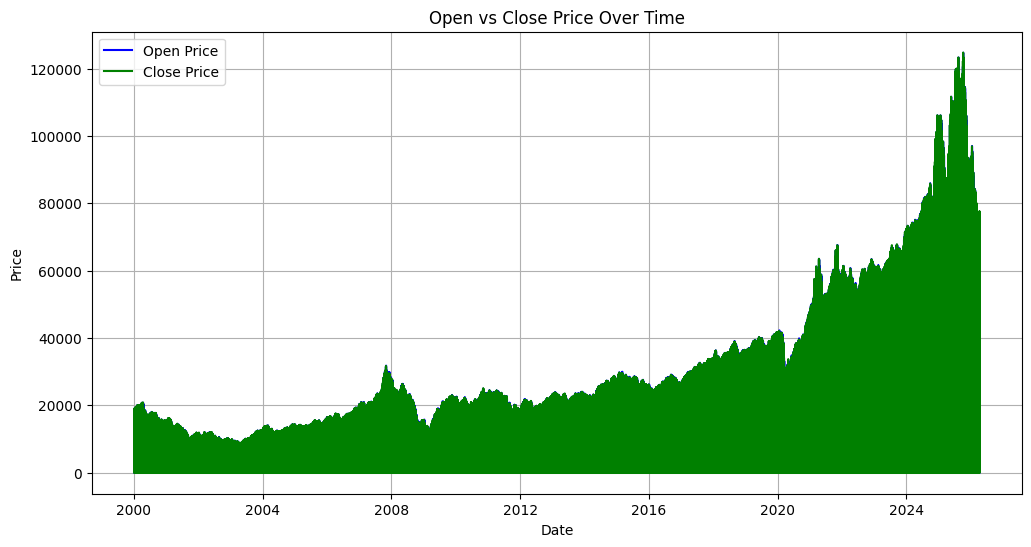

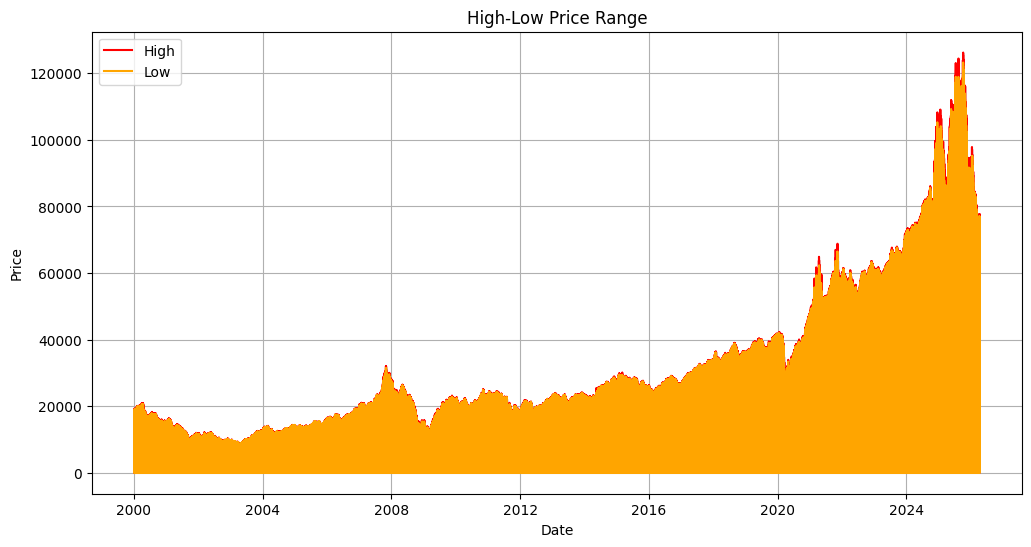

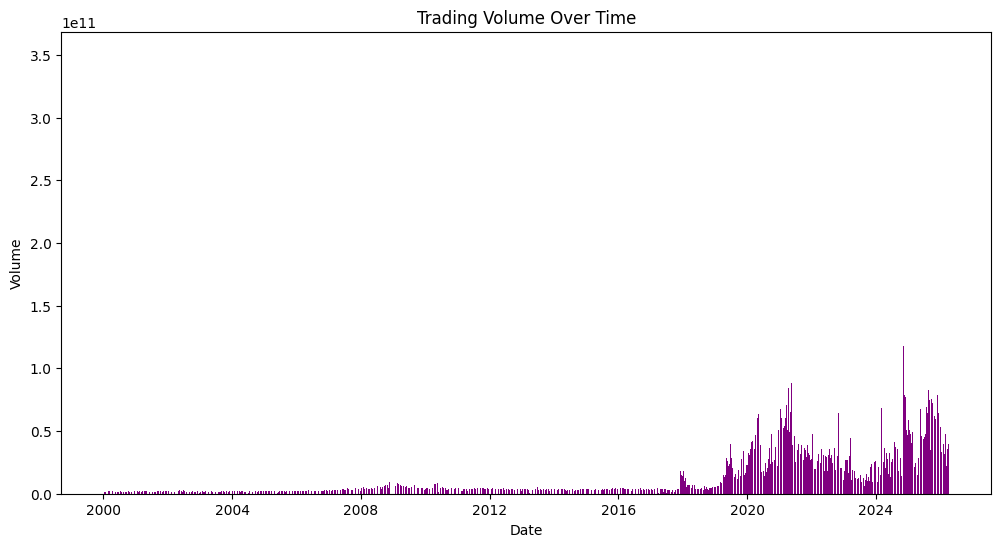

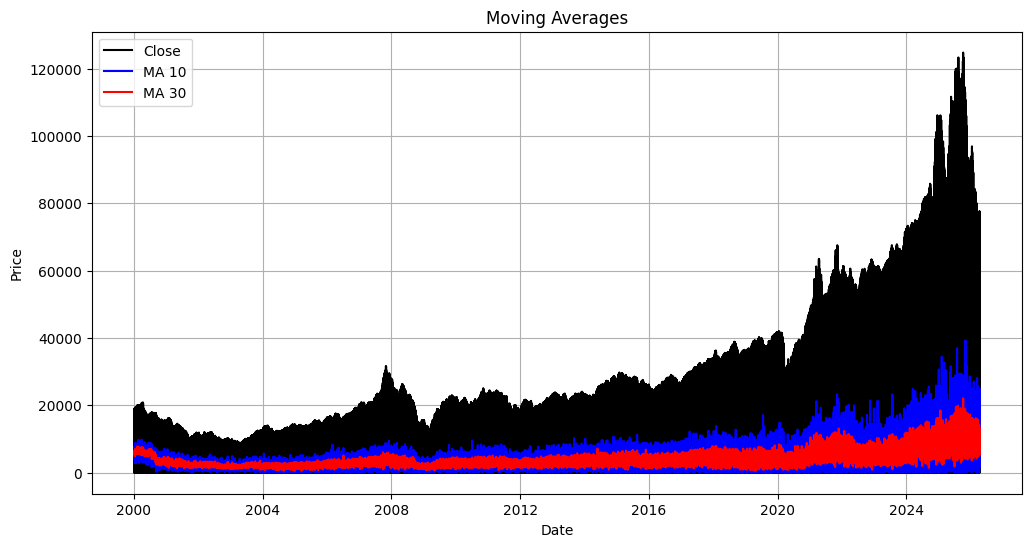

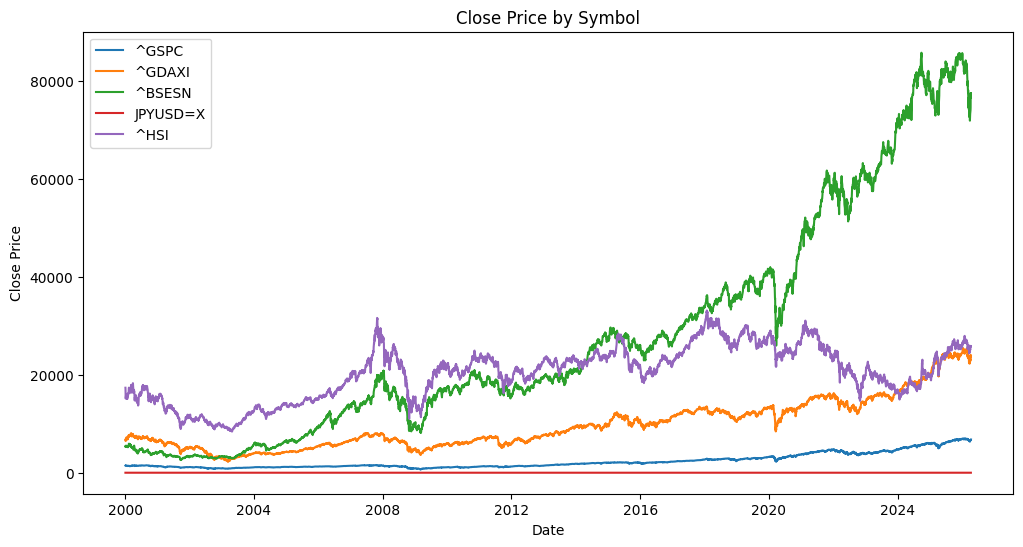

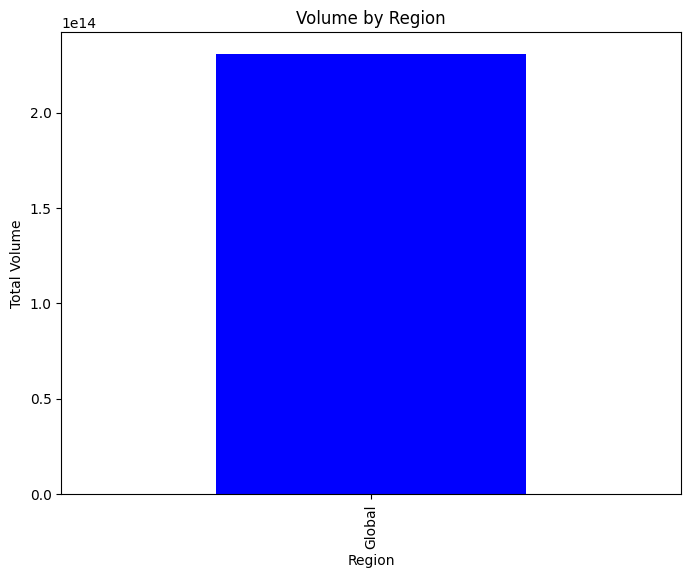

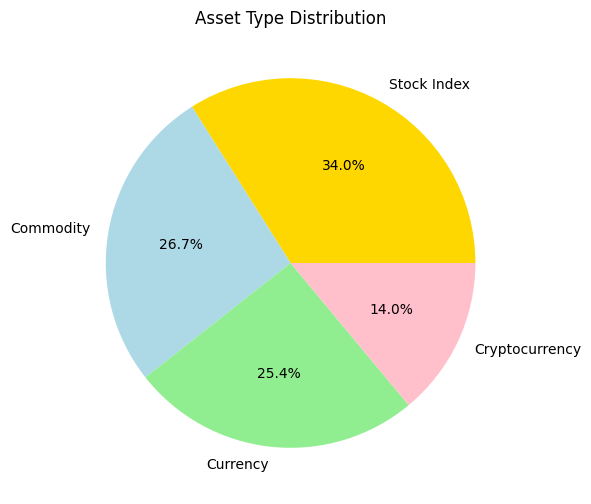

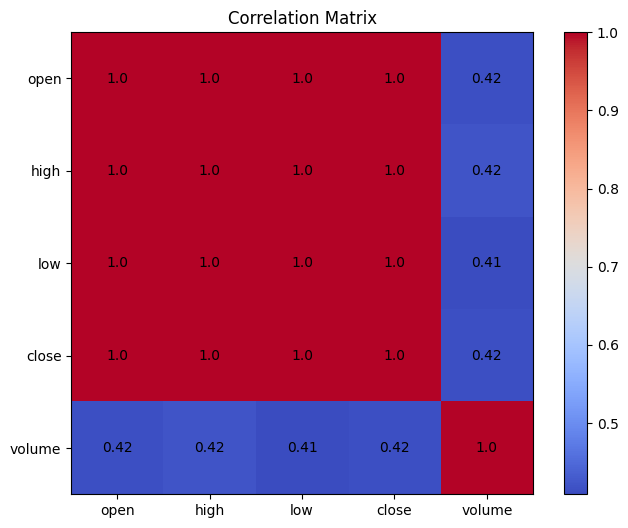

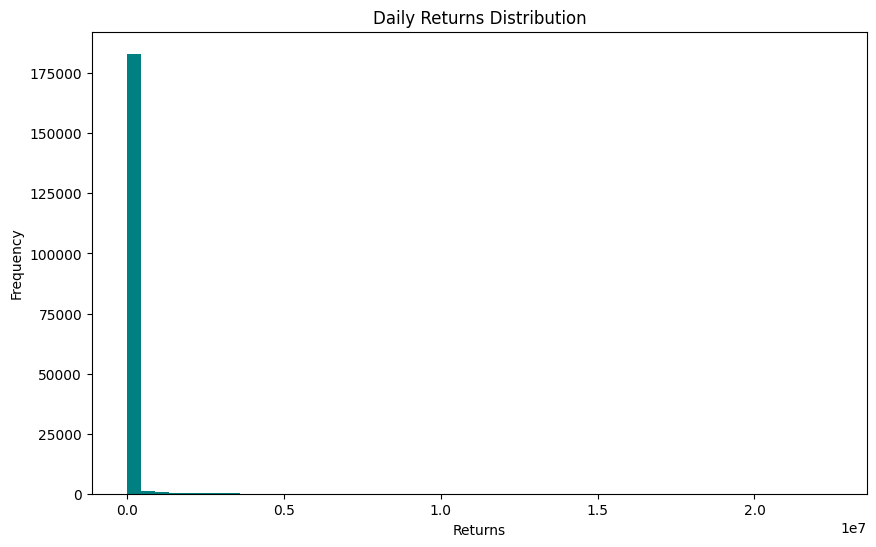

In [13]:
# ================================
# DATA PREPROCESSING
# ================================
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort values by date
df = df.sort_values(by='date')

# ================================
# BASIC INFO
# ================================
print(df.head())
print(df.info())

# ================================
# 1. LINE PLOT (OPEN, CLOSE)
# ================================
plt.figure(figsize=(12,6))

plt.plot(df['date'], df['open'], label='Open Price', color='blue')
plt.plot(df['date'], df['close'], label='Close Price', color='green')

plt.title('Open vs Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.show()

# ================================
# 2. HIGH-LOW RANGE PLOT
# ================================
plt.figure(figsize=(12,6))

plt.plot(df['date'], df['high'], label='High', color='red')
plt.plot(df['date'], df['low'], label='Low', color='orange')

plt.fill_between(df['date'], df['low'], df['high'], color='gray', alpha=0.2)

plt.title('High-Low Price Range')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.show()

# ================================
# 3. VOLUME BAR CHART
# ================================
plt.figure(figsize=(12,6))

plt.bar(df['date'], df['volume'], color='purple')

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

# ================================
# 4. MOVING AVERAGE (TREND)
# ================================
df['MA_10'] = df['close'].rolling(window=10).mean()
df['MA_30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(df['date'], df['close'], label='Close', color='black')
plt.plot(df['date'], df['MA_10'], label='MA 10', color='blue')
plt.plot(df['date'], df['MA_30'], label='MA 30', color='red')

plt.title('Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.show()

# ================================
# 5. SYMBOL-WISE ANALYSIS
# ================================
# If multiple symbols exist
symbols = df['symbol'].unique()

plt.figure(figsize=(12,6))

for sym in symbols[:5]:  # limit for readability
    temp = df[df['symbol'] == sym]
    plt.plot(temp['date'], temp['close'], label=sym)

plt.title('Close Price by Symbol')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

plt.show()

# ================================
# 6. REGION-WISE VOLUME
# ================================
region_volume = df.groupby('region')['volume'].sum()

plt.figure(figsize=(8,6))

region_volume.plot(kind='bar', color=['blue', 'green', 'red', 'orange'])

plt.title('Volume by Region')
plt.xlabel('Region')
plt.ylabel('Total Volume')

plt.show()

# ================================
# 7. ASSET TYPE DISTRIBUTION
# ================================
asset_counts = df['asset_type'].value_counts()

plt.figure(figsize=(8,6))

plt.pie(asset_counts, labels=asset_counts.index, autopct='%1.1f%%',
        colors=['gold', 'lightblue', 'lightgreen', 'pink'])

plt.title('Asset Type Distribution')

plt.show()

# ================================
# 8. CORRELATION HEATMAP (MANUAL)
# ================================
import numpy as np

corr = df[['open','high','low','close','volume']].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')

# Annotate values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='black')

plt.show()

# ================================
# 9. DAILY RETURNS DISTRIBUTION
# ================================
df['returns'] = df['close'].pct_change()

plt.figure(figsize=(10,6))

plt.hist(df['returns'].dropna(), bins=50, color='teal')

plt.title('Daily Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Frequency')

plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.7269
              precision    recall  f1-score   support

           0       0.81      0.59      0.68     18595
           1       0.68      0.86      0.76     18669

    accuracy                           0.73     37264
   macro avg       0.75      0.73      0.72     37264
weighted avg       0.75      0.73      0.72     37264


Random Forest
Accuracy: 0.7441
              precision    recall  f1-score   support

           0       0.73      0.77      0.75     18595
           1       0.76      0.71      0.74     18669

    accuracy                           0.74     37264
   macro avg       0.74      0.74      0.74     37264
weighted avg       0.74      0.74      0.74     37264


Gradient Boosting
Accuracy: 0.7518
              precision    recall  f1-score   support

           0       0.74      0.78      0.76     18595
           1       0.77      0.72      0.74     18669

    accuracy                           0.75     37264
   macro avg       0.7

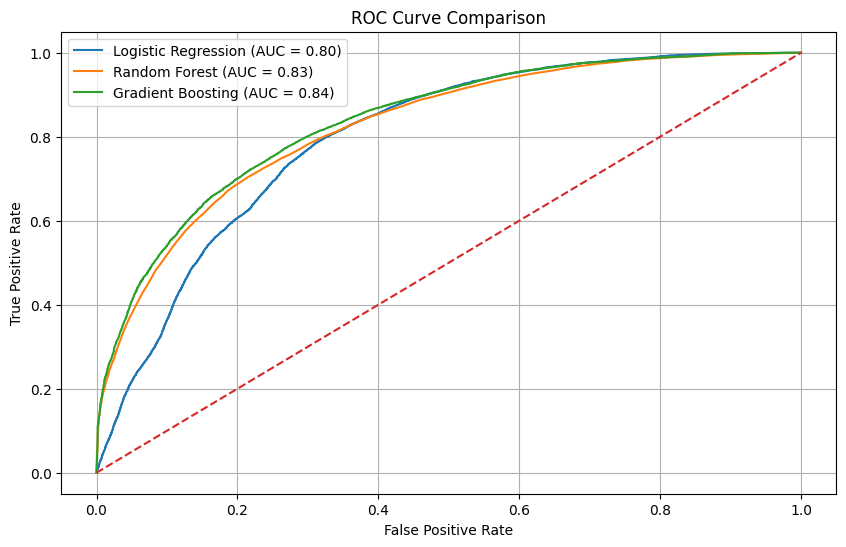


Best Model: Gradient Boosting
Best Accuracy: 0.7517711464147703


In [14]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# =====================================
# 3. PREPROCESSING
# =====================================
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')

# =====================================
# 4. FEATURE ENGINEERING (NO LEAKAGE)
# =====================================

# Create lag features (VERY IMPORTANT)
df['close_lag1'] = df['close'].shift(1)
df['close_lag2'] = df['close'].shift(2)

# Moving averages (past only)
df['ma_5'] = df['close'].rolling(5).mean().shift(1)
df['ma_10'] = df['close'].rolling(10).mean().shift(1)

# Returns (past info only)
df['returns'] = df['close'].pct_change().shift(1)

# =====================================
# 5. TARGET CREATION (NO FUTURE LEAKAGE)
# =====================================
# Predict: will price go UP tomorrow?

df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# =====================================
# 6. DROP NA (AFTER ALL SHIFTS)
# =====================================
df = df.dropna()

# =====================================
# 7. ENCODE CATEGORICAL FEATURES
# =====================================
le_symbol = LabelEncoder()
le_asset = LabelEncoder()
le_region = LabelEncoder()

df['symbol'] = le_symbol.fit_transform(df['symbol'])
df['asset_type'] = le_asset.fit_transform(df['asset_type'])
df['region'] = le_region.fit_transform(df['region'])

# =====================================
# 8. FEATURE SELECTION
# =====================================
features = [
    'open', 'high', 'low', 'volume',
    'symbol', 'asset_type', 'region',
    'close_lag1', 'close_lag2',
    'ma_5', 'ma_10', 'returns'
]

X = df[features]
y = df['target']

# =====================================
# 9. TIME-BASED TRAIN TEST SPLIT
# =====================================
# DO NOT shuffle (important for time series)

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# =====================================
# 10. SCALING (FIT ONLY ON TRAIN)
# =====================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================
# 11. MODELS
# =====================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

# =====================================
# 12. TRAIN + EVALUATE
# =====================================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("="*30)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =====================================
# 13. PLOT ROC CURVE
# =====================================
plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

# =====================================
# 14. BEST MODEL
# =====================================
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])

## Thank you..pls upvote!!!!!!!!!!